## PTID-AI-MAR-26-1134_PRAICP-1005-Image-Class-6

#### Import Libraries

In [89]:
import os
import sys
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import argparse
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

#### Configuration

In [90]:
import warnings
warnings.filterwarnings("ignore")

In [91]:
CSV_PATH = "/kaggle/input/datasets/bharaniamarnath/image-class-six-labels/images.csv"
IMAGES_DIR = "/kaggle/input/datasets/bharaniamarnath/image-class-six-labels/images"   # folder containing 0.jpg, 1.jpg, ...
NUM_CLASSES = 6
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 12
IMG_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_OUT = "best_model.pth"

#### Load Dataset

In [92]:
class ImageCsvDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, str(row["image_name"]))
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        return img, label

In [93]:
# Read CSV and split
df = pd.read_csv(CSV_PATH)

#### Train Test Data

In [94]:
train_df, val_df = train_test_split(df, test_size=0.15, stratify=df["label"], random_state=42)

#### Data Preprocessing

In [95]:
# Transforms
train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.1,0.1,0.1,0.01),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [96]:
train_ds = ImageCsvDataset(train_df, IMAGES_DIR, transform=train_tfms)
val_ds = ImageCsvDataset(val_df, IMAGES_DIR, transform=val_tfms)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

#### Build Model

In [97]:
# Model (simple CNN)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.BatchNorm2d(32), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.BatchNorm2d(64), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.BatchNorm2d(128), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.ReLU(), nn.BatchNorm2d(256), nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [98]:
model = SimpleCNN(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [99]:
import pandas as pd
from pathlib import Path

log_path = Path("training_log.csv")

def save_epoch_log(epoch, train_loss, val_loss, train_acc=None, val_acc=None, lr=None):
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "lr": lr,
    }
    df = pd.DataFrame([row])
    if log_path.exists():
        df.to_csv(log_path, mode="a", header=False, index=False)
    else:
        df.to_csv(log_path, index=False)


#### Model Training & Evaluation

In [100]:
best_val_acc = 0.0
for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in tqdm(train_loader, desc=f"Train {epoch}/{EPOCHS}"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    # Save Model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_acc": val_acc
        }, MODEL_OUT)
        print(f"Saved best model (val_acc={val_acc:.4f}) -> {MODEL_OUT}")

    save_epoch_log(epoch, train_loss, val_loss, train_acc, val_acc, lr=None)

    scheduler.step()

Train 1/12: 100%|██████████| 373/373 [00:19<00:00, 18.70it/s]


Epoch 1: train_loss=0.8975, train_acc=0.6466, val_loss=0.6357, val_acc=0.7635
Saved best model (val_acc=0.7635) -> best_model.pth


Train 2/12: 100%|██████████| 373/373 [00:19<00:00, 18.85it/s]


Epoch 2: train_loss=0.6382, train_acc=0.7648, val_loss=0.5971, val_acc=0.7811
Saved best model (val_acc=0.7811) -> best_model.pth


Train 3/12: 100%|██████████| 373/373 [00:20<00:00, 18.45it/s]


...

Epoch 10: train_loss=0.3077, train_acc=0.8908, val_loss=0.3520, val_acc=0.8799


Train 11/12: 100%|██████████| 373/373 [00:18<00:00, 19.76it/s]


Epoch 11: train_loss=0.2652, train_acc=0.9074, val_loss=0.2982, val_acc=0.9031
Saved best model (val_acc=0.9031) -> best_model.pth


Train 12/12: 100%|██████████| 373/373 [00:18<00:00, 19.78it/s]


Epoch 12: train_loss=0.2518, train_acc=0.9127, val_loss=0.3047, val_acc=0.8989


In [101]:
print("Training finished. Best val acc:", best_val_acc)

Training finished. Best val acc: 0.9031339031339032


### Predict Model

#### Configuration

In [102]:
MODEL_PATH = "best_model.pth"
JSON_PATH = "prediction.json"

#### Build Model

In [103]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.BatchNorm2d(32), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.BatchNorm2d(64), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.BatchNorm2d(128), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.ReLU(), nn.BatchNorm2d(256), nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

#### Preprocessing

In [104]:
tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

#### Load Model

In [105]:
def load_model(path, device):
    model = SimpleCNN(NUM_CLASSES).to(device)
    checkpoint = torch.load(path, map_location=device)
    # checkpoint may be a dict with 'model_state'
    state = checkpoint.get("model_state", checkpoint) if isinstance(checkpoint, dict) else checkpoint
    model.load_state_dict(state)
    model.eval()
    return model

In [106]:
def predict_image(model, img_path, device):
    img = Image.open(img_path).convert("RGB")
    tensor = tfms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1).cpu().squeeze(0).numpy()
        pred = int(probs.argmax())
    return {"predicted_label": pred, "probabilities": probs.tolist()}

In [107]:
def batch_predict(model, image_paths, device):
    results = {}
    for p in image_paths:
        if not os.path.exists(p):
            results[p] = {"error": "file not found"}
            continue
        results[p] = predict_image(model, p, device)
    return results

#### Run Prediction

In [108]:
if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Predict images with trained model")
    parser.add_argument("--model", type=str, default=MODEL_PATH)
    parser.add_argument("--input", type=str, required=True, nargs="+",
                        help="Path(s) to image file(s) to predict")
    parser.add_argument("--out", type=str, default=JSON_PATH,
                        help="Optional JSON output file (will be overwritten)")
    if len(sys.argv) == 1:
        sys.argv += ["--input", "/kaggle/input/datasets/bharaniamarnath/image-class-six-pred/"]
    args = parser.parse_args()

#### Load Saved Model

In [109]:
model = load_model(args.model, DEVICE)
input_paths = []

#### Load Dataset

In [110]:
for inp in args.input:
    if os.path.isdir(inp):
        # add all image files from directory
        for fname in sorted(os.listdir(inp)):
            if fname.lower().endswith((".jpg",".jpeg",".png")):
                input_paths.append(os.path.join(inp, fname))
    elif os.path.isfile(inp) and inp.lower().endswith((".csv")):
        # read CSV and build paths from image_name column
        import pandas as _pd
        df = _pd.read_csv(inp)
        def _ensure_ext(s):
            s = str(s)
            return s if s.lower().endswith((".jpg",".jpeg",".png")) else s + ".jpg"
        for n in df["image_name"].astype(str):
            input_paths.append(os.path.join(os.path.dirname(inp) if os.path.dirname(inp) else ".", _ensure_ext(n)))
    else:
        # assume it's a file path
        input_paths.append(inp)

#### Export Prediction

In [111]:
input_paths = [p for p in dict.fromkeys(input_paths) if os.path.exists(p)]

res = batch_predict(model, input_paths, DEVICE)

if args.out:
    with open(args.out, "w") as f:
        json.dump(res, f, indent=2)
    print(f"Wrote predictions to {args.out}")
else:
    print(json.dumps(res, indent=2))

Wrote predictions to prediction.json


### Data Analysis

#### Configuration

In [112]:
MODEL_PRED_JSON = "/kaggle/working/prediction.json"
TRAIN_LOG = "training_log.csv"
SAMPLES_PER_CLASS = 6
CLASS_NAMES = None

In [113]:
def ensure_ext_name(s):
    s = str(s)
    return s if s.lower().endswith((".jpg", ".jpeg", ".png")) else s + ".jpg"

In [114]:
def load_image(path, size=(IMG_SIZE,IMG_SIZE)):
    return Image.open(path).convert("RGB").resize(size)

#### Load Dataset

In [115]:
df = pd.read_csv(CSV_PATH)
if "image_name" in df.columns:
    df["image_name"] = df["image_name"].apply(ensure_ext_name)

In [116]:
print("Total samples:", len(df))
display(df.head())

Total samples: 14034


,image_name,label
0,0.jpg,0
1,1.jpg,4
2,2.jpg,5
3,4.jpg,0
4,7.jpg,4


In [117]:
# Class Distribution
dist = df["label"].value_counts().sort_index()
dist_df = dist.rename_axis("label").reset_index(name="count")
display(dist_df)

,label,count
0,0,2191
1,1,2271
2,2,2404
3,3,2512
4,4,2274
5,5,2382


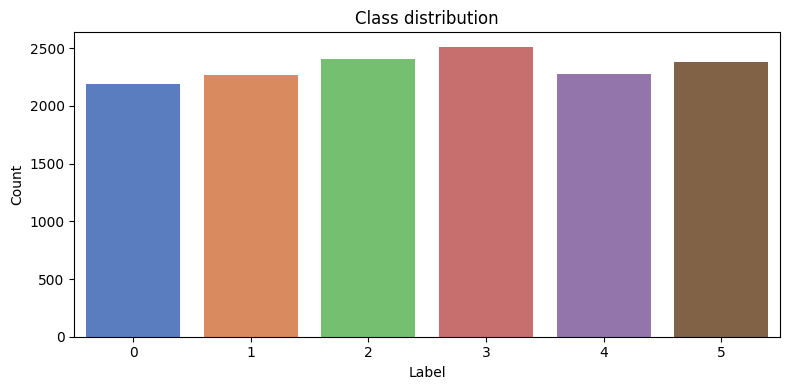

In [118]:
plt.figure(figsize=(8,4))
sns.barplot(x=dist_df["label"].astype(str), y=dist_df["count"], palette="muted")
plt.title("Class distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

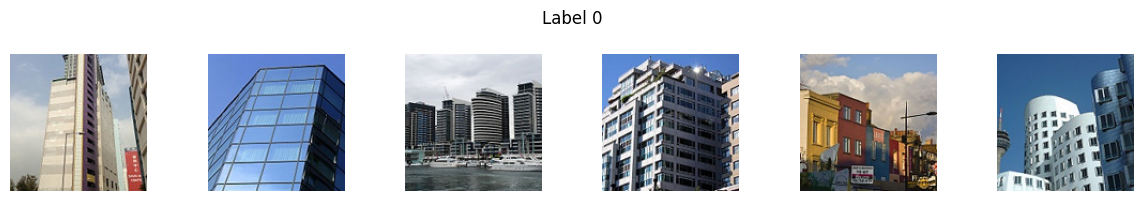

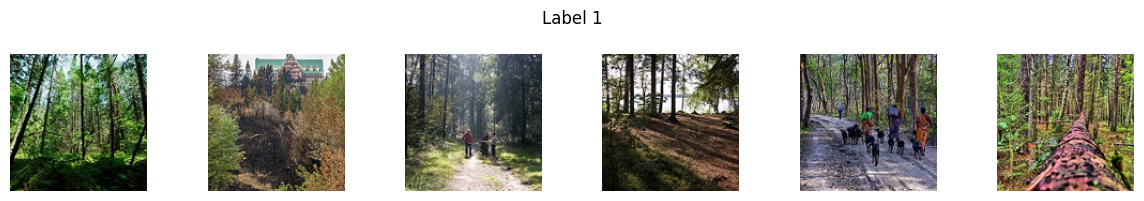

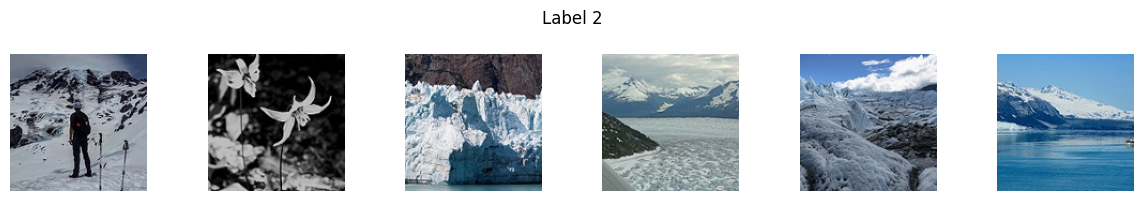

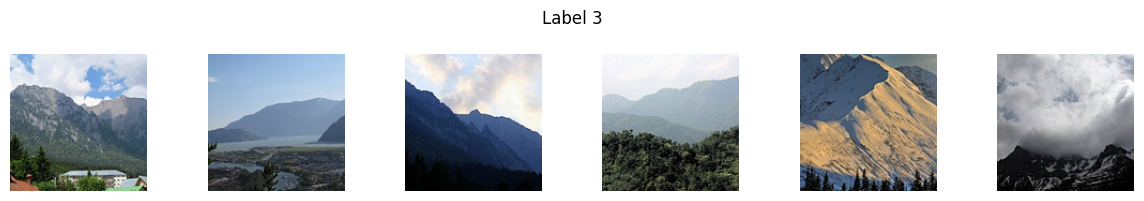

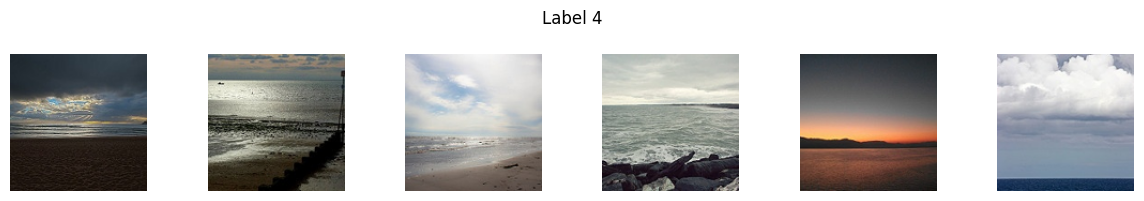

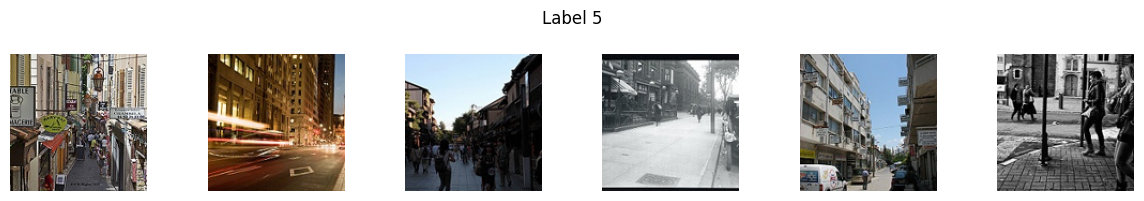

In [119]:
# Sample Images Per Class
unique_labels = sorted(df["label"].unique())
for lbl in unique_labels:
    rows = df[df["label"] == lbl].sample(min(SAMPLES_PER_CLASS, df[df["label"]==lbl].shape[0]), random_state=42)
    imgs = []
    for _, r in rows.iterrows():
        p = os.path.join(IMAGES_DIR, r["image_name"])
        if os.path.exists(p):
            imgs.append(load_image(p))
    if not imgs:
        continue
    cols = min(SAMPLES_PER_CLASS, len(imgs))
    fig, axes = plt.subplots(1, cols, figsize=(cols*2,2))
    if cols == 1:
        axes = [axes]
    for ax, im in zip(axes, imgs):
        ax.imshow(im)
        ax.axis("off")
    title = f"Label {lbl}" if CLASS_NAMES is None else f"{lbl}: {CLASS_NAMES[int(lbl)]}"
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [120]:
# Confusion Matrix & Classification Report
def analyze_predictions_display(pred_json_path):
    with open(pred_json_path, "r") as f:
        preds = json.load(f)
    rows = []
    for k,v in preds.items():
        name = os.path.basename(k)
        pred = v.get("predicted_label")
        rows.append({"image_name": name, "pred": int(pred)})
    pred_df = pd.DataFrame(rows)
    merged = df.merge(pred_df, on="image_name", how="inner")
    if merged.empty:
        print("No overlap between CSV and predictions.")
        return
    from sklearn.metrics import confusion_matrix, classification_report
    y_true = merged["label"].astype(int).values
    y_pred = merged["pred"].astype(int).values
    labels = sorted(list(set(y_true) | set(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    display(cm_df)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    report = classification_report(y_true, y_pred, labels=labels)
    print("Classification report:\n", report)

,0,1,2,3,4,5
0,0,0,0,0,0,1
1,0,0,0,1,0,0
2,0,0,0,0,1,0
3,0,0,0,0,0,0
4,0,1,0,0,0,0
5,1,0,1,0,0,0


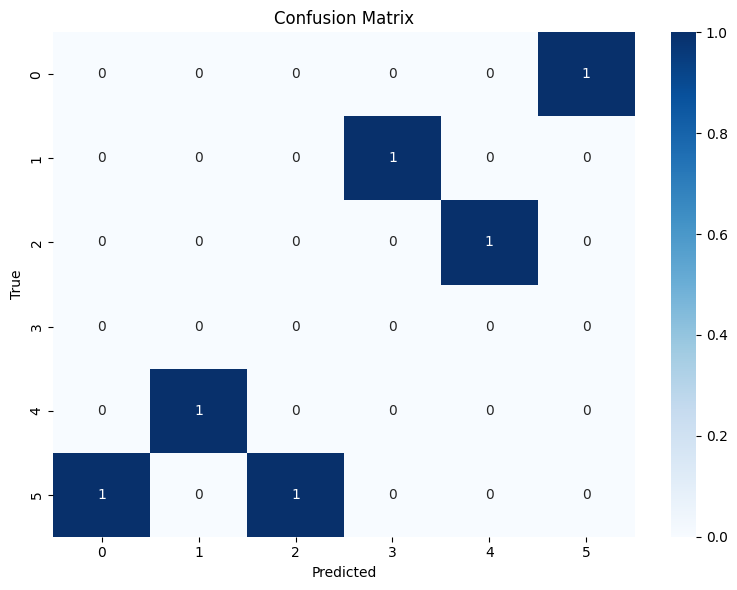

Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       1.0
           2       0.00      0.00      0.00       1.0
           3       0.00      0.00      0.00       0.0
           4       0.00      0.00      0.00       1.0
           5       0.00      0.00      0.00       2.0

    accuracy                           0.00       6.0
   macro avg       0.00      0.00      0.00       6.0
weighted avg       0.00      0.00      0.00       6.0



In [121]:
if MODEL_PRED_JSON and os.path.exists(MODEL_PRED_JSON):
    analyze_predictions_display(MODEL_PRED_JSON)
else:
    print("No predictions JSON provided; skipping prediction analysis. To analyze predictions, set MODEL_PRED_JSON to the JSON output from predict.py")

,epoch,train_loss,val_loss,train_acc,val_acc,lr
0,1,0.892377,0.636730,0.657780,0.765907,NaN
1,2,0.623896,0.518359,0.767606,0.818139,NaN
2,3,0.547995,0.511960,0.804913,0.812441,NaN
3,4,0.491441,0.504111,0.822770,0.826686,NaN
4,5,0.468683,0.382110,0.830818,0.867047,NaN


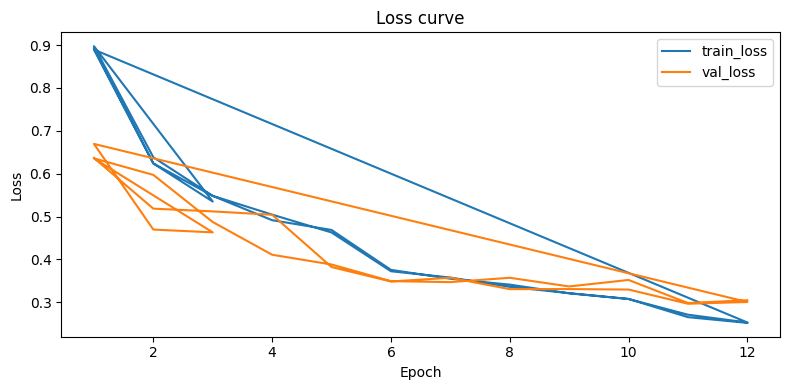

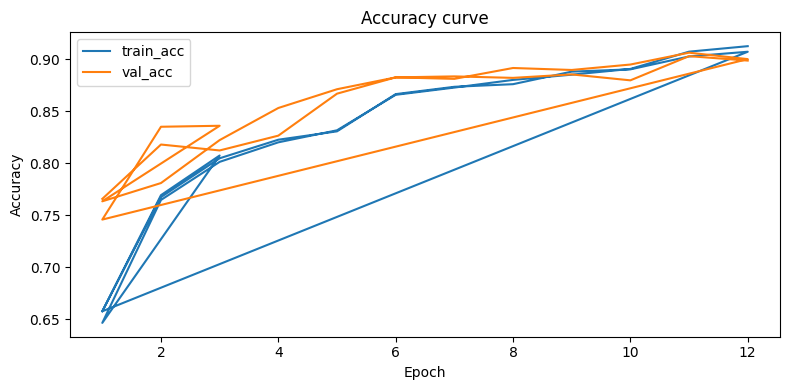

In [122]:
# Training Analysis
if os.path.exists(TRAIN_LOG):
    hist = pd.read_csv(TRAIN_LOG)
    display(hist.head())

    plt.figure(figsize=(8,4))
    plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
    plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss curve")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(hist["epoch"], hist["train_acc"], label="train_acc")
    plt.plot(hist["epoch"], hist["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy curve")
    plt.tight_layout()
    plt.show()
else:
    print("No training_log.csv found; to display training curves, save epoch metrics to training_log.csv during training.")